# Chunk 42 — Train, validate and test the surrogate on 12×12

**Data:** the Chunk 41 12×12 dataset — pool 5,600, val 700, test 700. Labels use `LABEL_MIN` (the minimum < −10 dB) throughout.

**Arms:**

| arm | starts from | trains on | recipe |
|---|---|---|---|
| `ft12` | `backbone_no55` (knowledge from 25/35/45) | 12×12 pool only | Adam lr 1e-4, batch 64, patience 10 |
| `ft12_replay` | `backbone_no55` | 12×12 pool, plus 5,600 replayed antennas from each of 25/35/45 per epoch | same |
| `scratch12` | random | 12×12 pool only (same GNN architecture) | Chunk 7: Adam lr 1e-3, batch 128, patience 20 |
| `cnn12` | random | 12×12 pool only: the Gupta et al. CNN on Gupta's own grid size, 42.8 M parameters | Chunk 36: NAdam lr 1e-3, batch 256, raw dB |

**Run queue, in priority order:**
1. every arm at 100%, seed 0
2. `ft12`, `scratch12` and `cnn12` at 100%, seed 1
3. `ft12` and `scratch12` at 25% and 50% of the pool — nested and prevalence-stratified — for the learning curve

**Protocol:**
- **Selection:** every arm selects its epoch and schedules its learning rate on **12×12 val MSE in raw dB**.
- **Test:** touched once. The fine-tuned models are also tested on 25/35/45 to measure forgetting.
- **Intervals:** paired stratified-bootstrap intervals.

**Pre-registered statements:**

| | question |
|---|---|
| S1 | **Transfer:** does fine-tuning beat the same GNN trained from scratch on 12×12? |
| S2 | **Data:** does fine-tuning on 25% or 50% of the pool beat training from scratch on 100%? This is the claim that "pretrained knowledge achieves what this dataset size alone could not". |
| S3 | **Forgetting:** how much do 25/35/45 degrade, with and without replay? |
| S4 | **GNN against CNN** on 12×12. |
| S5 | **Target:** does the best 12×12 test MSE fall below 0.5 dB²? |

**Writes:** only `ch42_*` artifacts and `checkpoints/ch42_*.pt`. Each checkpoint is force-flushed to Drive and verified by SHA-256.

## 1. Installs

In [1]:
!pip -q install torch_geometric pyarrow tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.1 MB/s eta 0:00:00


## 2. Repository and Drive

In [2]:
import os, sys, subprocess
REPO_ROOT = '/content/antenna_gnn'
if os.path.isdir(f'{REPO_ROOT}/.git'):
    subprocess.run(['git', '-C', REPO_ROOT, 'pull', '-q'], check=True)
else:
    subprocess.run(['git', 'clone', '-q', 'https://github.com/asparagusD/antenna_gnn.git', REPO_ROOT], check=True)
sys.path.insert(0, f'{REPO_ROOT}/src')
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
ART, CKPT, SPLITS, LOCAL = f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints', f'{DATA_ROOT}/splits', '/content/local_graphs'
os.makedirs(LOCAL, exist_ok=True)
print(REPO_ROOT, DATA_ROOT)

Mounted at /content/drive
/content/antenna_gnn /content/drive/MyDrive/antenna_gnn


## 3. Setup
**What it does:**
- Enables deterministic cuDNN and turns TF32 off.
- Hashes the input files and captures the mtimes of earlier ones.
- Loads the canonical 25×25 normalisation statistics read-only.
- **Requires Chunk 41's builder check to say "bit-identical",** proving the 12×12 graphs share the other grids' format.

In [3]:
# ── Setup: scope, provenance, determinism ──
import json, glob, hashlib, zipfile, shutil, time, math
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader as TorchLoader
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from model import AntennaGNN
from feed_component import AppendFeedComponentFeature

TAU, F = -10.0, np.linspace(1, 4, 201)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); assert DEVICE.type == 'cuda', 'GPU required'
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False; torch.backends.cudnn.allow_tf32 = False
def sha(p):
    h = hashlib.sha256()
    with open(p, 'rb') as f:
        for b in iter(lambda: f.read(1 << 20), b''):
            h.update(b)
    return h.hexdigest()
READ_SHA = {}
def READ(p):
    assert os.path.exists(p), f'missing {p}'
    READ_SHA.setdefault(p, sha(p)); return p
def OUT(n):
    assert n.startswith('ch42_'), n; return f'{ART}/{n}'
def COUT(n):
    assert n.startswith('ch42_') and n.endswith('.pt'), n; return f'{CKPT}/{n}'
PRIOR = {p: os.path.getmtime(p) for pat in (f'{ART}/*', f'{SPLITS}/*', f'{CKPT}/*.pt') for p in glob.glob(pat)
         if os.path.isfile(p) and not Path(p).name.startswith('ch42_')}
MEAN = torch.tensor(np.load(READ(f'{ART}/s11_mean.npy')), dtype=torch.float32)   # canonical 25x25 statistics, read only
STD = torch.tensor(np.load(READ(f'{ART}/s11_std.npy')), dtype=torch.float32)
MEAN_D, STD_D = MEAN.to(DEVICE), STD.to(DEVICE)
REP41 = json.load(open(READ(f'{ART}/ch41_report.json')))
assert 'bit-identical' in REP41['builder_check'], f'STOP: Chunk 41 builder check was "{REP41["builder_check"]}", not bit-identical'
TEST_TOUCHES = 0
print(f'Chunk 41 builder check: {REP41["builder_check"]}; captured mtimes of {len(PRIOR)} earlier files')

Chunk 41 builder check: bit-identical on 20 rebuilt 35x35 graphs; captured mtimes of 200 earlier files


## 4. Splits
12×12 comes from `finetune12_*` (Chunk 41); 25×25 from `indices.json`; 35/45 from the fine-tune files. The splits are asserted disjoint and equal to Chunk 41's sizes.

In [4]:
# ── Splits ──
def pairs(v):
    if isinstance(v, dict):
        return {(int(g), int(i)) for g, x in v.items() for i in x}
    return {(int(e[0]), int(e[1])) for e in v}
S = {12: {r: sorted(i for g, i in pairs(json.load(open(READ(f'{SPLITS}/finetune12_{r}_indices.json'))))) for r in ('pool', 'val', 'test')}}
IDX = json.load(open(READ(f'{SPLITS}/indices.json')))
S[25] = {'pool': sorted(i for g, i in pairs(IDX['train']) if g == 25), 'val': sorted(i for g, i in pairs(IDX['val']) if g == 25),
         'test': sorted(i for g, i in pairs(IDX['test']) if g == 25)}
FT = {r: pairs(json.load(open(READ(f'{SPLITS}/finetune_{r}_indices.json')))) for r in ('pool', 'val', 'test')}
for N in (35, 45):
    S[N] = {r: sorted(i for g, i in FT[r] if g == N) for r in ('pool', 'val', 'test')}
for N in S:
    a, b, c = (set(S[N][r]) for r in ('pool', 'val', 'test'))
    assert not (a & b or a & c or b & c), f'{N}: split overlap'
    print(f'{N}x{N}: pool/train {len(S[N]["pool"]):,} | val {len(S[N]["val"]):,} | test {len(S[N]["test"]):,}')
assert (len(S[12]['pool']), len(S[12]['val']), len(S[12]['test'])) == tuple(REP41['splits'][k] for k in ('pool', 'val', 'test'))

12x12: pool/train 5,600 | val 700 | test 700
25x25: pool/train 79,866 | val 9,984 | test 9,983
35x35: pool/train 3,990 | val 499 | test 499
45x45: pool/train 5,587 | val 698 | test 699


## 5. Stage and cache graphs; pool fractions
**What it does:**
- Unzips each grid's processed graphs to local SSD.
- Caches every graph in RAM the first time it's used, with the 8-connected feed-component column appended once.
- Builds 12×12 images and raw curves for the CNN.
- Builds nested, prevalence-stratified 25%/50%/100% fractions of the 12×12 pool (Chunk 37's method).

In [5]:
# ── Stage graphs; cache 6-feature graphs in RAM ──
def stage(N):
    d = f'{LOCAL}/{N}x{N}'
    if os.path.exists(f'{d}/_STAGED.txt'):
        return d
    os.makedirs(d, exist_ok=True)
    with zipfile.ZipFile(READ(f'{DATA_ROOT}/data/processed/processed_{N}x{N}.zip')) as Z:
        mem = [m for m in Z.namelist() if m.endswith('.pt')]
        for m in tqdm(mem, desc=f'stage {N}x{N}'):
            with Z.open(m) as a, open(f'{d}/{os.path.basename(m)}', 'wb') as b:
                shutil.copyfileobj(a, b)
    open(f'{d}/_STAGED.txt', 'w').write(str(len(mem)))
    return d
for N in (12, 25, 35, 45):
    stage(N)
TRANSFORM = AppendFeedComponentFeature()
CACHE = {}
def graph(N, i):
    """6-feature graph (feed-component column appended once and cached), raw-dB y_raw and normalised y."""
    k = (N, int(i))
    if k not in CACHE:
        d = torch.load(f'{LOCAL}/{N}x{N}/sample_{int(i)}.pt', weights_only=False)
        assert d.x.shape == (N * N + 1, 5) and float(d.x[-1, 3]) == -1.0 and d.y.numel() == 201 and float(d.y.max()) <= 0.01
        g = TRANSFORM(Data(x=d.x.clone(), edge_index=d.edge_index, edge_attr=d.edge_attr))
        y = d.y.reshape(1, 201).float()
        CACHE[k] = (g.x, g.edge_index, g.edge_attr, y)
    x, ei, ea, y = CACHE[k]
    return Data(x=x, edge_index=ei, edge_attr=ea, y=(y - MEAN) / (STD + 1e-8), y_raw=y)
def raw_curve(N, i):
    return graph(N, i).y_raw.reshape(-1).numpy()
LAB12 = np.array([raw_curve(12, i).min() < TAU for i in S[12]['pool']])
IMG = {r: torch.stack([graph(12, i).x[:-1, 0].reshape(1, 12, 12) for i in S[12][r]]) for r in ('pool', 'val', 'test')}
CUR = {r: torch.stack([graph(12, i).y_raw.reshape(-1) for i in S[12][r]]) for r in ('pool', 'val', 'test')}
print(f'12x12 pool functioning (LABEL_MIN) {LAB12.mean():.3f}; images {tuple(IMG["pool"].shape)}')

# nested, prevalence-stratified fractions of the 12x12 pool (Chunk 37 fractional-rank method)
def stratified_order(lab, rng):
    i0, i1 = rng.permutation(np.flatnonzero(~lab)), rng.permutation(np.flatnonzero(lab))
    key = np.r_[(np.arange(len(i0)) + rng.random(len(i0))) / len(i0), (np.arange(len(i1)) + rng.random(len(i1))) / len(i1)]
    return np.r_[i0, i1][np.argsort(key, kind='stable')]
ORDER = {s: stratified_order(LAB12, np.random.default_rng(420 + s)) for s in (0, 1)}
def pool_subset(frac, seed):
    k = int(round(frac * len(S[12]['pool']))); pos = np.sort(ORDER[seed][:k])
    assert abs(LAB12[pos].mean() - LAB12.mean()) <= 0.01
    return pos
for lo, hi in ((0.25, 0.5), (0.5, 1.0)):
    assert set(pool_subset(lo, 0)) <= set(pool_subset(hi, 0))
print('nested stratified fractions ready (25%, 50%, 100%)')

stage 12x12:   0%|          | 0/7000 [00:00<?, ?it/s]

stage 25x25:   0%|          | 0/99833 [00:00<?, ?it/s]

stage 35x35:   0%|          | 0/4988 [00:00<?, ?it/s]

stage 45x45:   0%|          | 0/6984 [00:00<?, ?it/s]

12x12 pool functioning (LABEL_MIN) 0.492; images (5600, 1, 12, 12)
nested stratified fractions ready (25%, 50%, 100%)


## 6. Models
**What it does:**
- **GNN:** six inputs, 587,129 parameters. The `ft12` arms start from `backbone_no55`, asserted to be the gated Chunk 30 checkpoint.
- **Gupta CNN at 12×12:** 42,771,473 parameters, close to the ~40 M of Gupta et al.'s own 12×12 model.
- Defines the predict helpers, all in raw dB.

In [6]:
# ── Models ──
def gnn(nf):
    return AntennaGNN(node_feat_dim=nf, edge_feat_dim=2, hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201)
class GuptaCNN(nn.Module):
    """Gupta et al. Fig. 4 forward CNN (Chunk 36 architecture) for an N x N input; at N = 12 this is Gupta's own grid."""
    def __init__(self, N):
        super().__init__()
        self.block1 = nn.Sequential(nn.Conv2d(1,64,5,padding=2), nn.BatchNorm2d(64), nn.LeakyReLU(.2), nn.Conv2d(64,64,5,padding=2),
                                    nn.BatchNorm2d(64), nn.LeakyReLU(.2), nn.Conv2d(64,64,5,padding=2), nn.BatchNorm2d(64), nn.LeakyReLU(.2))
        b2 = [nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(.2)]
        for _ in range(4): b2 += [nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(.2)]
        self.block2 = nn.Sequential(*b2)
        b3 = [nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(.2)]
        for _ in range(7): b3 += [nn.Conv2d(256,256,3,padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(.2)]
        self.block3 = nn.Sequential(*b3)
        self.fc = nn.Sequential(nn.Linear(256*N*N,1000), nn.BatchNorm1d(1000), nn.LeakyReLU(.2), nn.Dropout(.4),
                                nn.Linear(1000,500), nn.BatchNorm1d(500), nn.LeakyReLU(.2), nn.Dropout(.4), nn.Linear(500,201))
    def forward(self, x):
        return self.fc(self.block3(self.block2(self.block1(x))).flatten(1))
def n_par(m):
    return sum(p.numel() for p in m.parameters())
assert n_par(GuptaCNN(12)) == 42_771_473, n_par(GuptaCNN(12))      # 6,163,473 - 257,000 + 36,865,000
def state_of(path):
    c = torch.load(READ(path), map_location='cpu', weights_only=False)
    s = c['model_state'] if isinstance(c, dict) and 'model_state' in c else c
    return {k[7:] if k.startswith('module.') else k: v for k, v in s.items()}
BACKBONE = state_of(f'{CKPT}/backbone_no55.pt')
REP30 = json.load(open(READ(f'{ART}/ch30_backbone_report.json')))
assert sha(f'{CKPT}/backbone_no55.pt') == REP30['checkpoint_sha'], 'STOP: backbone_no55.pt is not the gated Chunk 30 checkpoint'
def backbone():
    m = gnn(6); m.load_state_dict(BACKBONE, strict=True); return m
best5 = gnn(5); best5.load_state_dict(state_of(f'{CKPT}/best_model.pt'), strict=True)
assert n_par(backbone()) == 587_129 and n_par(best5) == 587_001
print('GNN 587,129 params (6 inputs); Gupta CNN at 12x12: 42,771,473 params (close to Gupta et al.\'s ~40 M on their 12x12 grid)')

@torch.no_grad()
def predict_gnn(m, N, ids, nf=6, bs=128):
    m = m.to(DEVICE).eval(); out = []
    for s in range(0, len(ids), bs):
        gs = [graph(N, i) for i in ids[s:s + bs]]
        if nf == 5:
            gs = [Data(x=g.x[:, :5], edge_index=g.edge_index, edge_attr=g.edge_attr) for g in gs]
        out.append((m(next(iter(GeoLoader(gs, batch_size=len(gs)))).to(DEVICE)) * STD_D + MEAN_D).double().cpu())
    return torch.cat(out).numpy()
@torch.no_grad()
def predict_cnn(m, X, bs=256):
    m = m.to(DEVICE).eval()
    return torch.cat([m(X[s:s + bs].to(DEVICE)).double().cpu() for s in range(0, len(X), bs)]).numpy()
def truth(N, ids):
    return np.stack([raw_curve(N, i) for i in ids]).astype(np.float64)

GNN 587,129 params (6 inputs); Gupta CNN at 12x12: 42,771,473 params (close to Gupta et al.'s ~40 M on their 12x12 grid)


## 7. VAL harness (before training)
**What it checks:**
- `backbone_no55`'s zero-shot 12×12 val MSE reproduces Chunk 41.
- Its 25/35/45 val MSEs reproduce Chunk 30 (1.3692 / 1.3277 / 1.0966).
- It also prints the average-curve baseline.

In [7]:
# ── VAL harness (before any training) ──
bb = backbone()
v = predict_gnn(bb, 12, S[12]['val']); t = truth(12, S[12]['val'])
mse12 = float(((v - t) ** 2).mean())
print(f'backbone_no55 zero-shot 12x12 VAL MSE {mse12:.4f} | Chunk 41 report {REP41["zero_shot_val"]["backbone_no55"]["val_mse_db2"]:.4f}')
assert abs(mse12 - REP41['zero_shot_val']['backbone_no55']['val_mse_db2']) < 0.01, 'STOP: does not reproduce Chunk 41'
ref30 = {r['scope']: r.get('replay_mse') for r in REP30.get('per_scope', [])}
for N, ref in ((25, 1.3692), (35, 1.3277), (45, 1.0966)):
    m = float(((predict_gnn(bb, N, S[N]['val']) - truth(N, S[N]['val'])) ** 2).mean())
    print(f'backbone_no55 {N}x{N} VAL MSE {m:.4f} | Chunk 30/40 {ref:.4f}')
    assert abs(m - ref) < 0.01, f'STOP: backbone_no55 {N}x{N} VAL MSE does not reproduce Chunk 30'
BASE12 = float(((truth(12, S[12]['val']) - CUR['pool'].numpy().mean(0)) ** 2).mean())
print(f'average-curve baseline on 12x12 VAL: {BASE12:.4f} dB² (Chunk 41: 3.780)')
del bb; HARNESS = True

backbone_no55 zero-shot 12x12 VAL MSE 3.6915 | Chunk 41 report 3.6915
backbone_no55 25x25 VAL MSE 1.3692 | Chunk 30/40 1.3692
backbone_no55 35x35 VAL MSE 1.3277 | Chunk 30/40 1.3277
backbone_no55 45x45 VAL MSE 1.0966 | Chunk 30/40 1.0966
average-curve baseline on 12x12 VAL: 3.7797 dB² (Chunk 41: 3.780)


## 8. Train (resumable priority queue)
**What it does:**
- Runs the queue in order. A finished run is skipped, and the session budget stops the queue before a run would overrun.
- **Replay arm:** each epoch is the whole 12×12 pool plus 5,600 fresh random antennas from each of 25/35/45 (35×35 with replacement).
- **Forgetting monitor:** the fine-tune arms log val MSE on fixed 1,000-antenna subsets of 25/35/45 every 5 epochs.
- **Checkpoints:** the best model is kept on local SSD, then mirrored to Drive with a forced flush and a SHA check.
- **Interrupted runs:** a run cut short restarts from scratch (they're short); its old curve rows are removed first.

**Writes:** `ch42_curves.csv`, `ch42_runs.csv`, `checkpoints/ch42_<arm>_p<pct>_s<seed>.pt`.

In [9]:
# ── Training: four arms, resumable priority queue ──
#   ft12          GNN initialised from backbone_no55, fine-tuned on the 12x12 pool only
#   ft12_replay   the same, with 25/35/45 replay each epoch (Chunk 30 v2 EpochMix: 5,600 per grid)
#   scratch12     the same GNN architecture, random initialisation, 12x12 pool only (Chunk 7 recipe)
#   cnn12         Gupta et al. CNN at 12x12 (42.8 M parameters), random initialisation (Chunk 36 recipe)
# Selection and LR scheduling for every arm: 12x12 VAL MSE in raw dB (the reported metric).
RECIPE = {'ft12':        dict(lr=1e-4, wd=1e-4, batch=64,  patience=10, max_ep=150),
          'ft12_replay': dict(lr=1e-4, wd=1e-4, batch=64,  patience=10, max_ep=60),
          'scratch12':   dict(lr=1e-3, wd=1e-4, batch=128, patience=20, max_ep=400),
          'cnn12':       dict(lr=1e-3, wd=0.0,  batch=256, patience=10, max_ep=300)}
QUEUE = [('ft12', 1.0, 0), ('ft12_replay', 1.0, 0), ('scratch12', 1.0, 0), ('cnn12', 1.0, 0),
         ('ft12', 1.0, 1), ('scratch12', 1.0, 1), ('cnn12', 1.0, 1),
         ('ft12', 0.25, 0), ('ft12', 0.5, 0), ('scratch12', 0.25, 0), ('scratch12', 0.5, 0)]
CURVES, RUNS = OUT('ch42_curves.csv'), OUT('ch42_runs.csv')
SESSION_HOURS = 10; T0S = time.perf_counter(); TIMES = []
REPLAY_PER_GRID = 5600
MON = {N: sorted(np.random.default_rng(42).choice(S[N]['val'], min(1000, len(S[N]['val'])), replace=False).tolist()) for N in (25, 35, 45)}
def rid(arm, f, s): return f'{arm}_p{int(round(f * 100))}_s{s}'
def done(): return set(pd.read_csv(RUNS).run_id) if os.path.exists(RUNS) else set()
def append(df, p): df.to_csv(p, mode='a', header=not os.path.exists(p), index=False)
def mirror(local, drive_path):
    shutil.copy2(local, drive_path); h = sha(local)
    drive.flush_and_unmount(); drive.mount('/content/drive', force_remount=True)
    assert sha(drive_path) == h, f'STOP: {Path(drive_path).name} did not persist'
    return h
def val12(m, arm):
    P = predict_cnn(m, IMG['val']) if arm == 'cnn12' else predict_gnn(m, 12, S[12]['val'])
    T = CUR['val'].numpy().astype(np.float64)
    return float(((P - T) ** 2).mean()), float(np.abs(P - T).mean()), float(roc_auc_score(T.min(1) < TAU, -P.min(1)))

def train(arm, f, s):
    r = rid(arm, f, s); out = COUT(f'ch42_{r}.pt'); R_ = RECIPE[arm]
    if r in done() and os.path.exists(out):
        print('skip', r); return
    torch.manual_seed(1000 + s); torch.cuda.manual_seed_all(1000 + s); rng = np.random.default_rng(4200 + s)
    pos = pool_subset(f, s); pool_ids = [S[12]['pool'][p] for p in pos]
    if arm == 'cnn12':
        m = GuptaCNN(12); opt = torch.optim.NAdam(m.parameters(), lr=R_['lr'], weight_decay=R_['wd'])
        g = torch.Generator().manual_seed(2000 + s)
        loader = TorchLoader(TensorDataset(IMG['pool'][pos], CUR['pool'][pos]), batch_size=R_['batch'], shuffle=True, generator=g)
    else:
        m = backbone() if arm.startswith('ft12') else gnn(6)
        opt = torch.optim.Adam(m.parameters(), lr=R_['lr'], weight_decay=R_['wd'])
    m = m.to(DEVICE)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    best, bad, best_row, steps, t0 = float('inf'), 0, None, 0, time.perf_counter()
    best_local = f'/content/{r}.best'
    if os.path.exists(CURVES):
        C = pd.read_csv(CURVES); C[C.run_id != r].to_csv(CURVES, index=False)     # restart from scratch: no duplicate epochs
    for ep in tqdm(range(1, R_['max_ep'] + 1), desc=f'Training {r}'):
        m.train(); tot_mse, tot_mae, n = 0.0, 0.0, 0
        if arm == 'cnn12':
            batches = ((x.to(DEVICE), y.to(DEVICE)) for x, y in loader)
        else:
            keys = [(12, i) for i in pool_ids]
            if arm == 'ft12_replay':
                for N in (25, 35, 45):
                    keys += [(N, int(i)) for i in rng.choice(S[N]['pool'], REPLAY_PER_GRID, replace=len(S[N]['pool']) < REPLAY_PER_GRID)]
            order = rng.permutation(len(keys))
            batches = ((b.to(DEVICE), None) for b in GeoLoader([graph(*keys[j]) for j in order], batch_size=R_['batch'], shuffle=False))
        for x, y in batches:
            opt.zero_grad(set_to_none=True)
            if arm == 'cnn12':
                pred = m(x); loss = nn.functional.mse_loss(pred, y); nb = len(x)
                mae_val = nn.functional.l1_loss(pred, y).item()
            else:
                pred = m(x); target = x.y.view(-1, 201)
                loss = nn.functional.mse_loss(pred, target); nb = x.num_graphs
                mae_val = nn.functional.l1_loss(pred, target).item()
            loss.backward(); torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
            tot_mse += loss.item() * nb; tot_mae += mae_val * nb; n += nb; steps += 1

        # De-normalize GNN train loss to match raw-dB metrics of validation for intuitive comparison
        if arm == 'cnn12':
            train_mse, train_mae = tot_mse / n, tot_mae / n
        else:
            # Since validation metrics are in raw-dB, scale normalized GNN training loss back to approximate raw-dB
            # normalized_y = (y_raw - MEAN)/STD => train_mse_raw ~ train_mse * (STD^2) approx.
            std_mean = float(STD.pow(2).mean().item())
            std_mae = float(STD.mean().item())
            train_mse = (tot_mse / n) * std_mean
            train_mae = (tot_mae / n) * std_mae

        vmse, vmae, vauc = val12(m, arm); sch.step(vmse)
        print(f'[Epoch {ep:03d}] Train MSE: {train_mse:.4f} | Train MAE: {train_mae:.4f} || Val MSE: {vmse:.4f} | Val MAE: {vmae:.4f}')
        row = dict(run_id=r, arm=arm, fraction=f, seed=s, epoch=ep, steps=steps, wall_seconds=time.perf_counter() - t0,
                   train_loss=tot_mse / n, val12_mse_db2=vmse, val12_mae_db=vmae, val12_auroc=vauc, lr=opt.param_groups[0]['lr'])
        if arm.startswith('ft12') and (ep == 1 or ep % 5 == 0):
            for N in (25, 35, 45):
                row[f'val{N}_mse_db2'] = float(((predict_gnn(m, N, MON[N]) - truth(N, MON[N])) ** 2).mean())
            m.train()
        append(pd.DataFrame([row]), CURVES)
        if vmse < best:
            best, bad, best_row = vmse, 0, row
            torch.save({'model_state': m.state_dict(), 'arm': arm, 'fraction': f, 'seed': s, 'best_epoch': ep, 'best_val12_mse': vmse,
                        'n_train_12x12': len(pool_ids)}, best_local)
        else:
            bad += 1
        if bad >= R_['patience']:
            break
    h = mirror(best_local, out)
    rec = dict(run_id=r, arm=arm, fraction=f, seed=s, n_train_12x12=len(pool_ids), n_params=n_par(m), best_epoch=best_row['epoch'],
               epochs_run=ep, minutes=(time.perf_counter() - t0) / 60, minutes_to_best=best_row['wall_seconds'] / 60,
               val12_mse_db2=best_row['val12_mse_db2'], val12_mae_db=best_row['val12_mae_db'], val12_auroc=best_row['val12_auroc'],
               budget_limited=bool(best_row['epoch'] > R_['max_ep'] - R_['patience']), checkpoint=out, checkpoint_sha256=h)
    append(pd.DataFrame([rec]), RUNS); TIMES.append(rec['minutes'] * 60); os.remove(best_local)
    del m, opt; torch.cuda.empty_cache()
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in rec.items() if k not in ('checkpoint', 'checkpoint_sha256')})

assert globals().get('HARNESS') is True
for job in QUEUE:
    used = (time.perf_counter() - T0S) / 3600
    if TIMES and used + np.mean(TIMES) / 3600 > SESSION_HOURS:
        print(f'session budget reached ({used:.1f} h): re-run this cell in a new session to continue'); break
    train(*job)
print('completed:', len(done()), 'of', len(QUEUE))

Training ft12_p100_s0:   0%|          | 0/150 [00:00<?, ?it/s]

[Epoch 001] Train MSE: 2.4071 | Train MAE: 0.3972 || Val MSE: 2.2307 | Val MAE: 0.5523
[Epoch 002] Train MSE: 2.2347 | Train MAE: 0.3690 || Val MSE: 2.1622 | Val MAE: 0.5344
[Epoch 003] Train MSE: 2.1827 | Train MAE: 0.3595 || Val MSE: 2.1373 | Val MAE: 0.5367
[Epoch 004] Train MSE: 2.1554 | Train MAE: 0.3538 || Val MSE: 2.1283 | Val MAE: 0.5306
[Epoch 005] Train MSE: 2.1308 | Train MAE: 0.3504 || Val MSE: 2.1126 | Val MAE: 0.5318
[Epoch 006] Train MSE: 2.1169 | Train MAE: 0.3475 || Val MSE: 2.0992 | Val MAE: 0.5228
[Epoch 007] Train MSE: 2.0999 | Train MAE: 0.3451 || Val MSE: 2.0874 | Val MAE: 0.5253
[Epoch 008] Train MSE: 2.0880 | Train MAE: 0.3426 || Val MSE: 2.0648 | Val MAE: 0.5189
[Epoch 009] Train MSE: 2.0792 | Train MAE: 0.3422 || Val MSE: 2.0829 | Val MAE: 0.5272
[Epoch 010] Train MSE: 2.0646 | Train MAE: 0.3410 || Val MSE: 2.0450 | Val MAE: 0.5172
[Epoch 011] Train MSE: 2.0557 | Train MAE: 0.3392 || Val MSE: 2.0980 | Val MAE: 0.5264
[Epoch 012] Train MSE: 2.0402 | Train MAE: 

Training ft12_replay_p100_s0:   0%|          | 0/60 [00:00<?, ?it/s]

[Epoch 001] Train MSE: 2.3860 | Train MAE: 0.3445 || Val MSE: 2.3358 | Val MAE: 0.5672
[Epoch 002] Train MSE: 2.2849 | Train MAE: 0.3388 || Val MSE: 2.2661 | Val MAE: 0.5660
[Epoch 003] Train MSE: 2.2999 | Train MAE: 0.3365 || Val MSE: 2.2275 | Val MAE: 0.5552
[Epoch 004] Train MSE: 2.3867 | Train MAE: 0.3383 || Val MSE: 2.1846 | Val MAE: 0.5521
[Epoch 005] Train MSE: 2.3651 | Train MAE: 0.3355 || Val MSE: 2.1837 | Val MAE: 0.5564
[Epoch 006] Train MSE: 2.2726 | Train MAE: 0.3358 || Val MSE: 2.1561 | Val MAE: 0.5394
[Epoch 007] Train MSE: 2.4356 | Train MAE: 0.3396 || Val MSE: 2.1806 | Val MAE: 0.5497
[Epoch 008] Train MSE: 2.3639 | Train MAE: 0.3357 || Val MSE: 2.1455 | Val MAE: 0.5369
[Epoch 009] Train MSE: 2.4099 | Train MAE: 0.3374 || Val MSE: 2.1516 | Val MAE: 0.5556
[Epoch 010] Train MSE: 2.3589 | Train MAE: 0.3352 || Val MSE: 2.1318 | Val MAE: 0.5407
[Epoch 011] Train MSE: 2.2714 | Train MAE: 0.3294 || Val MSE: 2.1238 | Val MAE: 0.5400
[Epoch 012] Train MSE: 2.3222 | Train MAE: 

Training scratch12_p100_s0:   0%|          | 0/400 [00:00<?, ?it/s]

...

[Epoch 001] Train MSE: 2.5158 | Train MAE: 0.4143 || Val MSE: 2.2658 | Val MAE: 0.5659
[Epoch 002] Train MSE: 2.3065 | Train MAE: 0.3812 || Val MSE: 2.2149 | Val MAE: 0.5535
[Epoch 003] Train MSE: 2.2525 | Train MAE: 0.3735 || Val MSE: 2.1884 | Val MAE: 0.5449
[Epoch 004] Train MSE: 2.2239 | Train MAE: 0.3662 || Val MSE: 2.1690 | Val MAE: 0.5406
[Epoch 005] Train MSE: 2.1866 | Train MAE: 0.3606 || Val MSE: 2.1605 | Val MAE: 0.5485
[Epoch 006] Train MSE: 2.1741 | Train MAE: 0.3598 || Val MSE: 2.1411 | Val MAE: 0.5342
[Epoch 007] Train MSE: 2.1395 | Train MAE: 0.3532 || Val MSE: 2.1284 | Val MAE: 0.5362
[Epoch 008] Train MSE: 2.1248 | Train MAE: 0.3521 || Val MSE: 2.1198 | Val MAE: 0.5292
[Epoch 009] Train MSE: 2.1086 | Train MAE: 0.3500 || Val MSE: 2.1075 | Val MAE: 0.5374
[Epoch 010] Train MSE: 2.1049 | Train MAE: 0.3515 || Val MSE: 2.1075 | Val MAE: 0.5273
[Epoch 011] Train MSE: 2.0925 | Train MAE: 0.3468 || Val MSE: 2.1591 | Val MAE: 0.5450
[Epoch 012] Train MSE: 2.0841 | Train MAE: 

Training scratch12_p25_s0:   0%|          | 0/400 [00:00<?, ?it/s]

[Epoch 001] Train MSE: 3.6390 | Train MAE: 0.6715 || Val MSE: 3.8242 | Val MAE: 0.8104
[Epoch 002] Train MSE: 3.2441 | Train MAE: 0.5969 || Val MSE: 3.8038 | Val MAE: 0.8083
[Epoch 003] Train MSE: 3.1888 | Train MAE: 0.5868 || Val MSE: 3.6301 | Val MAE: 0.7925
[Epoch 004] Train MSE: 3.0349 | Train MAE: 0.5564 || Val MSE: 3.2981 | Val MAE: 0.7418
[Epoch 005] Train MSE: 2.9295 | Train MAE: 0.5336 || Val MSE: 3.2692 | Val MAE: 0.6836
[Epoch 006] Train MSE: 2.8869 | Train MAE: 0.5195 || Val MSE: 3.1356 | Val MAE: 0.7098
[Epoch 007] Train MSE: 2.8075 | Train MAE: 0.5028 || Val MSE: 3.0229 | Val MAE: 0.6851
[Epoch 008] Train MSE: 2.7667 | Train MAE: 0.4912 || Val MSE: 3.0425 | Val MAE: 0.7137
[Epoch 009] Train MSE: 2.7429 | Train MAE: 0.4873 || Val MSE: 3.0099 | Val MAE: 0.7097
[Epoch 010] Train MSE: 2.7233 | Train MAE: 0.4809 || Val MSE: 3.0126 | Val MAE: 0.7073
[Epoch 011] Train MSE: 2.6979 | Train MAE: 0.4723 || Val MSE: 2.9080 | Val MAE: 0.6836
[Epoch 012] Train MSE: 2.6779 | Train MAE: 

Training scratch12_p50_s0:   0%|          | 0/400 [00:00<?, ?it/s]

[Epoch 001] Train MSE: 3.5230 | Train MAE: 0.6401 || Val MSE: 3.8249 | Val MAE: 0.8261
[Epoch 002] Train MSE: 3.2285 | Train MAE: 0.5832 || Val MSE: 3.4126 | Val MAE: 0.7575
[Epoch 003] Train MSE: 2.9854 | Train MAE: 0.5353 || Val MSE: 3.2881 | Val MAE: 0.6973
[Epoch 004] Train MSE: 2.8869 | Train MAE: 0.5108 || Val MSE: 3.0548 | Val MAE: 0.6978
[Epoch 005] Train MSE: 2.8104 | Train MAE: 0.4879 || Val MSE: 2.9785 | Val MAE: 0.6967
[Epoch 006] Train MSE: 2.7441 | Train MAE: 0.4742 || Val MSE: 2.9081 | Val MAE: 0.6779
[Epoch 007] Train MSE: 2.7207 | Train MAE: 0.4651 || Val MSE: 2.8513 | Val MAE: 0.6811
[Epoch 008] Train MSE: 2.6971 | Train MAE: 0.4593 || Val MSE: 2.8071 | Val MAE: 0.6596
[Epoch 009] Train MSE: 2.6805 | Train MAE: 0.4554 || Val MSE: 2.8049 | Val MAE: 0.6738
[Epoch 010] Train MSE: 2.6560 | Train MAE: 0.4539 || Val MSE: 2.7649 | Val MAE: 0.6390
[Epoch 011] Train MSE: 2.6590 | Train MAE: 0.4501 || Val MSE: 2.8053 | Val MAE: 0.6894
[Epoch 012] Train MSE: 2.6335 | Train MAE: 

## 9. TEST TOUCH
The only cell that scores test graphs, guarded by a counter.

**What it scores:**
- every ch42 run on 12×12 test
- the 100% seed-0 fine-tunes on 25/35/45 test, for forgetting
- the references: `backbone_no55` and `best_model` zero-shot, and the average-curve predictor

**Writes:** `ch42_per_sample.parquet`.

In [10]:
# ── TEST TOUCH (the only cell that scores test graphs) ──
assert globals().get('HARNESS') is True and TEST_TOUCHES == 0; TEST_TOUCHES += 1
RUNS_DF = pd.read_csv(RUNS)
PRED, TRUE = {}, {N: truth(N, S[N]['test']) for N in (12, 25, 35, 45)}
for rr in RUNS_DF.itertuples():
    st = state_of(rr.checkpoint)
    if rr.arm == 'cnn12':
        m = GuptaCNN(12); m.load_state_dict(st, strict=True); PRED[(rr.run_id, 12)] = predict_cnn(m, IMG['test'])
    else:
        m = gnn(6); m.load_state_dict(st, strict=True); PRED[(rr.run_id, 12)] = predict_gnn(m, 12, S[12]['test'])
        if rr.fraction == 1.0 and rr.seed == 0:              # forgetting: the 100% seed-0 fine-tunes on the other grids
            for N in (25, 35, 45):
                PRED[(rr.run_id, N)] = predict_gnn(m, N, S[N]['test'])
    del m; torch.cuda.empty_cache()
for N in (12, 25, 35, 45):                                   # references
    PRED[('backbone_no55', N)] = predict_gnn(backbone(), N, S[N]['test'])
    PRED[('best_model', N)] = predict_gnn(best5, N, S[N]['test'], nf=5)
PRED[('average_curve', 12)] = np.repeat(CUR['pool'].numpy().mean(0, keepdims=True).astype(np.float64), len(S[12]['test']), 0)
rows = []
for (mid, N), P in PRED.items():
    T = TRUE[N]
    for k, li in enumerate(S[N]['test']):
        rows.append(dict(model_id=mid, grid=N, local_idx=li, true_min_db=T[k].min(), pred_min_db=P[k].min(),
                         mse_db2=((P[k] - T[k]) ** 2).mean(), mae_db=np.abs(P[k] - T[k]).mean()))
PER = pd.DataFrame(rows); PER.to_parquet(OUT('ch42_per_sample.parquet'), index=False)
print(f'TEST touched once: {PER.model_id.nunique()} models; {len(PER):,} rows')

TEST touched once: 14 models; 65,705 rows


## 10. Metrics, paired comparisons, statements
**Metrics per model and grid:** MSE, RMSE, MAE, R², AUROC, and skill against the average curve, with 95% stratified bootstrap intervals (rng 421).

**Paired comparisons** (same test antennas, rng 422):
- `ft12` against `scratch12`, per seed
- replay against no replay
- each GNN arm against `cnn12`
- the 25% and 50% fine-tunes against scratch at 100%
- the forgetting pairs on 25/35/45

**Statements:** S1–S5 are answered from these verdicts.

**Writes:** `ch42_metrics.csv`, `ch42_paired.csv`.

In [11]:
# ── Metrics with 95% intervals, paired comparisons, pre-registered statements ──
R = 1000
def stats(mid, N, rng):
    P, T = PRED[(mid, N)], TRUE[N]; mse = ((P - T) ** 2).mean(1); mae = np.abs(P - T).mean(1)
    y = (T.min(1) < TAU).astype(int); s = -P.min(1); sse = ((P - T) ** 2).sum(1)
    base = ((T - CUR['pool'].numpy().mean(0)) ** 2).mean() if N == 12 else np.nan
    pt = dict(mse_db2=mse.mean(), rmse_db=np.sqrt(mse.mean()), mae_db=mae.mean(), r2=1 - sse.sum() / ((T - T.mean()) ** 2).sum(),
              auroc=roc_auc_score(y, s) if np.std(s) > 0 else np.nan, skill=1 - mse.mean() / base if N == 12 else np.nan)
    i0, i1 = np.flatnonzero(y == 0), np.flatnonzero(y == 1); reps = {k: np.empty(R) for k in ('mse_db2', 'mae_db', 'r2')}
    for r_ in range(R):
        ii = np.r_[rng.choice(i0, len(i0)), rng.choice(i1, len(i1))]
        reps['mse_db2'][r_] = mse[ii].mean(); reps['mae_db'][r_] = mae[ii].mean()
        reps['r2'][r_] = 1 - sse[ii].sum() / ((T[ii] - T[ii].mean()) ** 2).sum()
    return pt, reps
rows = []
for (mid, N) in PRED:
    pt, reps = stats(mid, N, np.random.default_rng(421))
    for k, v in pt.items():
        lo, hi = np.quantile(reps[k], [.025, .975]) if k in reps else (np.nan, np.nan)
        rows.append(dict(model_id=mid, grid=N, metric=k, estimate=v, lo=lo, hi=hi))
MET = pd.DataFrame(rows); MET.to_csv(OUT('ch42_metrics.csv'), index=False)
def val(mid, N, k):
    r = MET[(MET.model_id == mid) & (MET.grid == N) & (MET.metric == k)]
    return None if r.empty else r.iloc[0]

def paired(a, b, N, k='mse'):
    A = PER[(PER.model_id == a) & (PER.grid == N)].sort_values('local_idx'); B = PER[(PER.model_id == b) & (PER.grid == N)].sort_values('local_idx')
    if A.empty or B.empty: return None
    col = 'mse_db2' if k == 'mse' else 'mae_db'; d = A[col].values - B[col].values
    y = (A.true_min_db.values < TAU); i0, i1 = np.flatnonzero(~y), np.flatnonzero(y); rng = np.random.default_rng(422)
    reps = np.array([d[np.r_[rng.choice(i0, len(i0)), rng.choice(i1, len(i1))]].mean() for _ in range(R)])
    lo, hi = np.quantile(reps, [.025, .975])
    return dict(grid=N, A=a, B=b, metric=k, A_minus_B=d.mean(), lo=lo, hi=hi,
                verdict='A better' if hi < 0 else ('B better' if lo > 0 else 'no significant difference'))
ids = set(RUNS_DF.run_id)
pairs_ = [('ft12_p100_s0', 'scratch12_p100_s0', 12), ('ft12_p100_s1', 'scratch12_p100_s1', 12),
          ('ft12_replay_p100_s0', 'ft12_p100_s0', 12), ('ft12_p100_s0', 'cnn12_p100_s0', 12), ('ft12_p100_s1', 'cnn12_p100_s1', 12),
          ('ft12_replay_p100_s0', 'cnn12_p100_s0', 12), ('scratch12_p100_s0', 'cnn12_p100_s0', 12),
          ('ft12_p25_s0', 'scratch12_p100_s0', 12), ('ft12_p50_s0', 'scratch12_p100_s0', 12),
          ('ft12_p100_s0', 'backbone_no55', 12)]
pairs_ += [(a, 'backbone_no55', N) for a in ('ft12_p100_s0', 'ft12_replay_p100_s0') for N in (25, 35, 45)]
PAIR = pd.DataFrame([p for a, b, N in pairs_ for k in ('mse', 'mae') if (a in ids or a == 'backbone_no55') and (b in ids or b == 'backbone_no55')
                     for p in [paired(a, b, N, k)] if p is not None])
PAIR.to_csv(OUT('ch42_paired.csv'), index=False)
print(PAIR.round(4).to_string(index=False))

def verdict(a, b, N, k='mse'):
    r = PAIR[(PAIR.A == a) & (PAIR.B == b) & (PAIR.grid == N) & (PAIR.metric == k)]
    return None if r.empty else r.iloc[0].verdict
ANS = {}
s1 = [verdict(f'ft12_p100_s{s}', f'scratch12_p100_s{s}', 12, k) for s in (0, 1) for k in ('mse', 'mae')]
s1 = [v for v in s1 if v]; ANS['S1 transfer: fine-tuned GNN beats the same GNN trained from scratch on 12x12 (every seed, MSE and MAE)'] = \
    'YES' if s1 and all(v == 'A better' for v in s1) else ('NO' if s1 and not any(v == 'A better' for v in s1) else 'MIXED')
for f in (0.25, 0.5):
    v = verdict(f'ft12_p{int(f*100)}_s0', 'scratch12_p100_s0', 12)
    ANS[f'S2 data: fine-tuning on {int(f*100)}% of the pool vs scratch on 100% (MSE)'] = \
        {None: 'not run', 'A better': f'fine-tune on {int(f*100)}% is BETTER than scratch on 100%',
         'B better': f'scratch on 100% is better', 'no significant difference': 'tied'}[v]
rep = {N: PAIR[(PAIR.A == 'ft12_replay_p100_s0') & (PAIR.B == 'backbone_no55') & (PAIR.grid == N) & (PAIR.metric == 'mse')] for N in (25, 35, 45)}
nor = {N: PAIR[(PAIR.A == 'ft12_p100_s0') & (PAIR.B == 'backbone_no55') & (PAIR.grid == N) & (PAIR.metric == 'mse')] for N in (25, 35, 45)}
ANS['S3 forgetting (MSE change on 25/35/45 vs backbone_no55): no replay | with replay'] = '; '.join(
    f'{N}x{N}: {nor[N].A_minus_B.iloc[0]:+.3f} | ' + (f'{rep[N].A_minus_B.iloc[0]:+.3f}' if len(rep[N]) else 'n/a') for N in (25, 35, 45) if len(nor[N]))
ANS['S3b replay effect on 12x12 (replay - no replay, MSE)'] = verdict('ft12_replay_p100_s0', 'ft12_p100_s0', 12) or 'not run'
s4 = [verdict(f'ft12_p100_s{s}', f'cnn12_p100_s{s}', 12, k) for s in (0, 1) for k in ('mse', 'mae')]
s4 = [v for v in s4 if v]; ANS['S4 fine-tuned GNN vs Gupta CNN trained on 12x12 (every seed, MSE and MAE)'] = \
    'GNN better' if s4 and all(v == 'A better' for v in s4) else ('CNN better' if s4 and all(v == 'B better' for v in s4) else 'MIXED / tied')
best_id = min((i for i in ids if i.endswith('p100_s0') and i != 'cnn12_p100_s0'), key=lambda i: val(i, 12, 'mse_db2').estimate)
b = val(best_id, 12, 'mse_db2')
ANS['S5 best GNN arm 12x12 test MSE vs the 0.5 dB² aspiration'] = (f'{best_id}: {b.estimate:.3f} [{b.lo:.3f}, {b.hi:.3f}] dB² -> '
    + ('below 0.5 (interval entirely below)' if b.hi < 0.5 else ('above 0.5 (interval entirely above)' if b.lo > 0.5 else 'interval contains 0.5')))
print('\nPRE-REGISTERED STATEMENTS')
for k, v in ANS.items(): print(f'  {k}:\n      {v}')

 grid                   A                 B metric  A_minus_B      lo      hi                   verdict
   12        ft12_p100_s0 scratch12_p100_s0    mse    -0.1979 -0.2744 -0.1138                  A better
   12        ft12_p100_s0 scratch12_p100_s0    mae    -0.0466 -0.0585 -0.0350                  A better
   12        ft12_p100_s1 scratch12_p100_s1    mse    -0.1384 -0.2026 -0.0694                  A better
   12        ft12_p100_s1 scratch12_p100_s1    mae    -0.0244 -0.0351 -0.0131                  A better
   12 ft12_replay_p100_s0      ft12_p100_s0    mse     0.0584  0.0181  0.0989                  B better
   12 ft12_replay_p100_s0      ft12_p100_s0    mae     0.0127  0.0065  0.0193                  B better
   12        ft12_p100_s0     cnn12_p100_s0    mse    -0.5159 -0.6114 -0.4221                  A better
   12        ft12_p100_s0     cnn12_p100_s0    mae    -0.0755 -0.0903 -0.0614                  A better
   12        ft12_p100_s1     cnn12_p100_s1    mse    -0.6586 -0

## 11. Figure and report
**Figure, three panels:**
- (a) 12×12 test MSE for every arm and reference
- (b) fine-tuned against from-scratch MSE as the 12×12 training set grows
- (c) 25/35/45 test MSE before and after the 12×12 fine-tune, with and without replay

**Report:** tables, paired verdicts, S1–S5, and the run table, with Gupta et al.'s 0.71 mentioned as context only.

**Writes:** `ch42_results.png`, `ch42_report.md`.

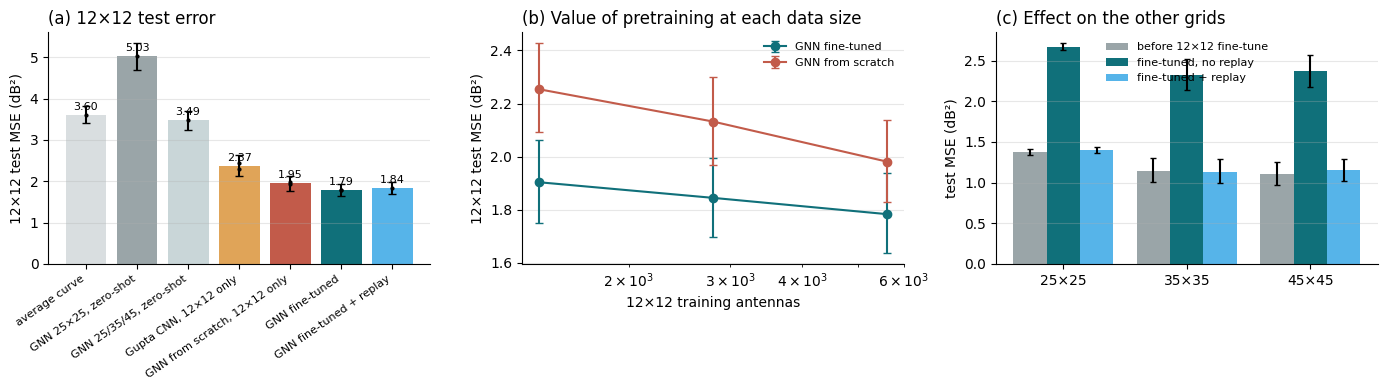

# Chunk 42 — Training, validating and testing on the 12×12 dataset

12×12 splits: pool 5,600 / val 700 / test 700. Selection on 12×12 val MSE only; one test touch; 95% stratified bootstrap intervals.

## 12×12 test
| model | MSE (dB²) | MAE (dB) | R² | AUROC | skill vs average curve |
|---|---|---|---|---|---|
| average_curve | 3.603 [3.408, 3.824] | 0.797 [0.782, 0.812] | 0.327 [0.310, 0.345] | nan | 0.000 |
| best_model | 5.035 [4.701, 5.338] | 0.868 [0.834, 0.895] | 0.060 [-0.017, 0.133] | 0.787 | -0.397 |
| backbone_no55 | 3.490 [3.252, 3.699] | 0.734 [0.708, 0.756] | 0.349 [0.300, 0.399] | 0.777 | 0.032 |
| cnn12_p100_s0 | 2.300 [2.126, 2.466] | 0.560 [0.541, 0.579] | 0.571 [0.541, 0.600] | 0.763 | 0.362 |
| cnn12_p100_s1 | 2.446 [2.251, 2.634] | 0.589 [0.570, 0.607] | 0.544 [0.516, 0.572] | 0.768 | 0.321 |
| ft12_p100_s0 | 1.784 [1.636, 1.939] | 0.485 [0.467, 0.501] | 0.667 [0.641, 0.693] | 0.796 | 0.505 |
| ft12_p100_s1 | 1.787 [1.635, 1.941] | 0.487 [0.469, 0.504] | 0.666 [0.64

In [12]:
# ── Figure and report ──
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
arms = [('average_curve', 'average curve', '#D9DEE0'), ('best_model', 'GNN 25×25, zero-shot', '#9AA5A8'),
        ('backbone_no55', 'GNN 25/35/45, zero-shot', '#C9D6D8'), ('cnn12', 'Gupta CNN, 12×12 only', '#E0A458'),
        ('scratch12', 'GNN from scratch, 12×12 only', '#C25B4A'), ('ft12', 'GNN fine-tuned', '#10707A'),
        ('ft12_replay', 'GNN fine-tuned + replay', '#56B4E9')]
xs, ys, lo, hi, cs, labels = [], [], [], [], [], []
for j, (key, lab, col) in enumerate(arms):
    mids = [key] if key in ('average_curve', 'best_model', 'backbone_no55') else sorted(i for i in ids if i.startswith(f'{key}_p100_'))
    if key == 'ft12':
        mids = [i for i in mids if not i.startswith('ft12_replay')]
    vals = [val(mm, 12, 'mse_db2') for mm in mids]; vals = [v for v in vals if v is not None]
    if not vals: continue
    e = np.mean([v.estimate for v in vals]); xs.append(len(xs)); ys.append(e); cs.append(col); labels.append(lab)
    lo.append(e - min(v.lo for v in vals)); hi.append(max(v.hi for v in vals) - e)
    for v in vals: ax[0].plot(xs[-1], v.estimate, 'k.', ms=4, zorder=5)
ax[0].bar(xs, ys, color=cs, yerr=[lo, hi], capsize=3)
for x_, y_ in zip(xs, ys): ax[0].text(x_, y_ + 0.12, f'{y_:.2f}', ha='center', fontsize=8)
ax[0].set_xticks(xs); ax[0].set_xticklabels(labels, rotation=35, ha='right', fontsize=8); ax[0].set_ylabel('12×12 test MSE (dB²)')
ax[0].set_title('(a) 12×12 test error', loc='left')
for key, col, lab in (('ft12', '#10707A', 'fine-tuned'), ('scratch12', '#C25B4A', 'from scratch')):
    pts = [(f, val(f'{key}_p{int(f*100)}_s0', 12, 'mse_db2')) for f in (0.25, 0.5, 1.0)]
    pts = [(f, v) for f, v in pts if v is not None]
    if pts:
        n = [f * len(S[12]['pool']) for f, _ in pts]
        ax[1].errorbar(n, [v.estimate for _, v in pts], yerr=[[v.estimate - v.lo for _, v in pts], [v.hi - v.estimate for _, v in pts]],
                       marker='o', color=col, capsize=3, label=f'GNN {lab}')
ax[1].set_xscale('log'); ax[1].set_xlabel('12×12 training antennas'); ax[1].set_ylabel('12×12 test MSE (dB²)')
ax[1].set_title('(b) Value of pretraining at each data size', loc='left'); ax[1].legend(frameon=False, fontsize=8)
w = 0.27
for j, (mid, col, lab) in enumerate((('backbone_no55', '#9AA5A8', 'before 12×12 fine-tune'), ('ft12_p100_s0', '#10707A', 'fine-tuned, no replay'),
                                    ('ft12_replay_p100_s0', '#56B4E9', 'fine-tuned + replay'))):
    v = [val(mid, N, 'mse_db2') for N in (25, 35, 45)]
    if any(x is None for x in v): continue
    ax[2].bar(np.arange(3) + (j - 1) * w, [x.estimate for x in v], w, color=col, label=lab,
              yerr=[[x.estimate - x.lo for x in v], [x.hi - x.estimate for x in v]], capsize=2)
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(['25×25', '35×35', '45×45']); ax[2].set_ylabel('test MSE (dB²)')
ax[2].set_title('(c) Effect on the other grids', loc='left'); ax[2].legend(frameon=False, fontsize=8)
for a in ax: a.grid(alpha=.3, axis='y'); a.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); fig.savefig(OUT('ch42_results.png'), dpi=200); plt.show()

def fmt(mid, N, k):
    v = val(mid, N, k)
    if v is None: return '—'
    return f'{v.estimate:.3f}' if np.isnan(v.lo) else f'{v.estimate:.3f} [{v.lo:.3f}, {v.hi:.3f}]'
order = ['average_curve', 'best_model', 'backbone_no55'] + sorted(i for i in ids)
L = ['# Chunk 42 — Training, validating and testing on the 12×12 dataset', '',
     f'12×12 splits: pool {len(S[12]["pool"]):,} / val {len(S[12]["val"]):,} / test {len(S[12]["test"]):,}. '
     'Selection on 12×12 val MSE only; one test touch; 95% stratified bootstrap intervals.', '',
     '## 12×12 test', '| model | MSE (dB²) | MAE (dB) | R² | AUROC | skill vs average curve |', '|---|---|---|---|---|---|']
for mid in order:
    if val(mid, 12, 'mse_db2') is None: continue
    L.append(f'| {mid} | {fmt(mid, 12, "mse_db2")} | {fmt(mid, 12, "mae_db")} | {fmt(mid, 12, "r2")} | {fmt(mid, 12, "auroc")} | {fmt(mid, 12, "skill")} |')
L += ['', '## Other grids (forgetting check)', '| model | 25×25 MSE | 35×35 MSE | 45×45 MSE |', '|---|---|---|---|']
for mid in ('backbone_no55', 'best_model', 'ft12_p100_s0', 'ft12_replay_p100_s0'):
    if val(mid, 25, 'mse_db2') is not None:
        L.append(f'| {mid} | ' + ' | '.join(fmt(mid, N, 'mse_db2') for N in (25, 35, 45)) + ' |')
L += ['', '## Paired comparisons (A − B, same test antennas)', PAIR.round(4).to_markdown(index=False), '',
      '## Pre-registered statements'] + [f'- **{k}:** {v}' for k, v in ANS.items()]
L += ['', '## Runs', pd.read_csv(RUNS).drop(columns=['checkpoint_sha256']).round(4).to_markdown(index=False), '',
      '_Context only: Gupta et al. (TAP 2023) report a validation loss of 0.71 on 12×12 patterns (81 points, 10–20 GHz, ~400k '
      'training antennas, units not stated). Our 12×12 numbers are on a different band, patch, substrate and frequency grid, '
      'so they are not a head-to-head comparison._']
open(OUT('ch42_report.md'), 'w').write('\n'.join(L) + '\n'); print('\n'.join(L))

## 12. Guards
**What it checks:**
- one test touch
- every checkpoint matches its recorded SHA-256
- inputs unchanged and earlier files unmodified
- no run stopped by its epoch cap
- every output is named `ch42_*`

In [13]:
# ── Guards ──
fails = []
def guard(ok, msg):
    print(f"  [{'PASS' if ok else 'FAIL'}] {msg}")
    if not ok: fails.append(msg)
guard(TEST_TOUCHES == 1, 'TEST touched exactly once')
R2 = pd.read_csv(RUNS)
guard(all(sha(p) == h for p, h in zip(R2.checkpoint, R2.checkpoint_sha256)), 'every ch42 checkpoint matches its recorded SHA-256')
guard(all(sha(p) == h for p, h in READ_SHA.items() if not Path(p).name.startswith('ch42_')), f'input files unchanged ({len(READ_SHA)})')
guard(all(os.path.getmtime(p) == t for p, t in PRIOR.items() if os.path.exists(p)), f'no earlier file modified ({len(PRIOR)})')
guard(not R2.budget_limited.any(), 'no run stopped by its epoch cap' if not R2.budget_limited.any() else
      f'BUDGET-LIMITED runs: {list(R2[R2.budget_limited].run_id)}')
guard(all(Path(p).name.startswith('ch42_') for p in glob.glob(f'{ART}/ch42_*') + glob.glob(f'{CKPT}/ch42_*')), 'all outputs ch42_*')
assert not fails, fails
print('ALL GUARDS PASSED')

  [PASS] TEST touched exactly once
  [PASS] every ch42 checkpoint matches its recorded SHA-256
  [PASS] input files unchanged (28)
  [PASS] no earlier file modified (200)
  [PASS] no run stopped by its epoch cap
  [PASS] all outputs ch42_*
ALL GUARDS PASSED
